In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
plt.style.use("tableau-colorblind10")

In [17]:
OUTPUT_DIR = "outputs"

In [18]:
data = {}
for file in os.listdir(OUTPUT_DIR):
    if file.endswith(".csv"):
        name = file.replace("_rollout.csv", "")
        path = os.path.join(OUTPUT_DIR, file)
        df = pd.read_csv(path)
        data[name] = df

# ensure same length
min_len = min(len(df) for df in data.values())
for k in data:
    data[k] = data[k].iloc[:min_len].reset_index(drop=True)

In [19]:
summary = []

for name, df in data.items():
    total_reward = df["reward"].sum()
    avg_reward = df["reward"].mean()
    final_theta = df["theta"].iloc[-1]
    final_thetadot = df["thetadot"].iloc[-1]
    control_effort = np.sum(df["control"]**2)

    summary.append({
        "algo": name,
        "total_reward": total_reward,
        "avg_reward": avg_reward,
        "final_theta": final_theta,
        "final_thetadot": final_thetadot,
        "control_energy": control_effort
    })

summary_df = pd.DataFrame(summary).sort_values("total_reward", ascending=False)
print(summary_df)

      algo  total_reward  avg_reward   final_theta  final_thetadot  \
2      sac     -4.997131   -0.004992 -6.617546e-03   -2.146078e-06   
3     ddpg     -6.738868   -0.006732  1.693630e-02    3.202667e-07   
1  trajopt     -8.699990   -0.008691 -3.794751e-21   -4.036596e-20   
0      td3    -24.929466   -0.024905 -9.737086e-02   -6.363179e-06   

   control_energy  
2        6.482864  
3        4.988016  
1       11.928877  
0        9.813157  


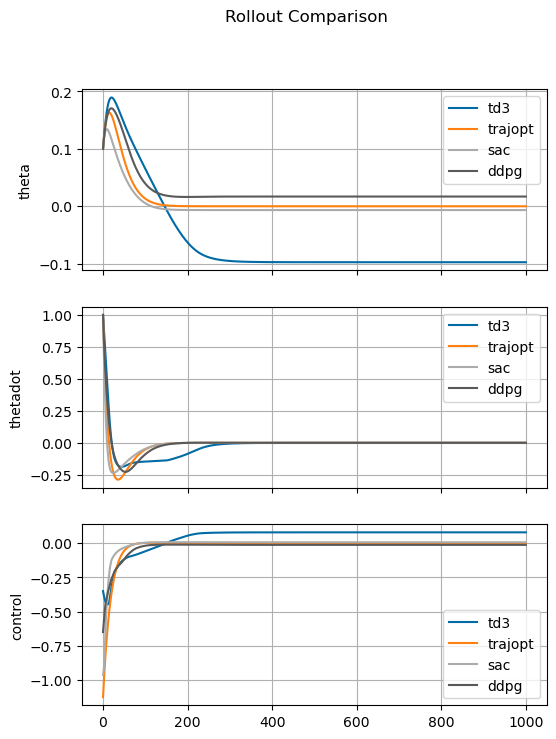

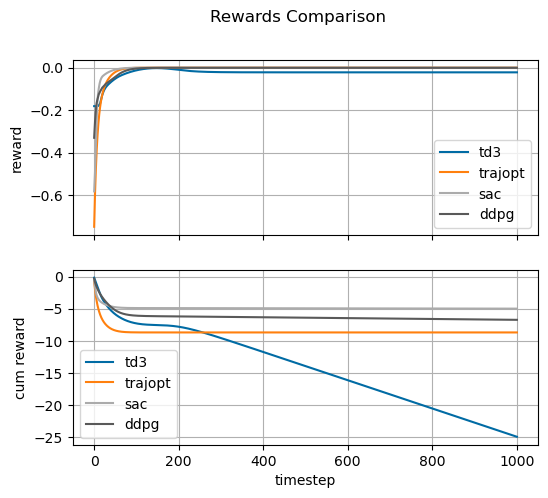

In [20]:
timesteps = np.arange(min_len)

fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# theta
for name, df in data.items():
    axs[0].plot(timesteps, df["theta"], label=name)
axs[0].set_ylabel("theta")
axs[0].grid(True)

# thetadot
for name, df in data.items():
    axs[1].plot(timesteps, df["thetadot"], label=name)
axs[1].set_ylabel("thetadot")
axs[1].grid(True)

# control
for name, df in data.items():
    axs[2].plot(timesteps, df["control"], label=name)
axs[2].set_ylabel("control")
axs[2].grid(True)

axs[0].legend()
axs[1].legend()
axs[2].legend()

fig.suptitle("Rollout Comparison")


fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# reward
for name, df in data.items():
    axs[0].plot(timesteps, df["reward"], label=name)
axs[0].set_ylabel("reward")
axs[0].grid(True)

# cumulative reward
for name, df in data.items():
    axs[1].plot(timesteps, df["reward"].cumsum(), label=name)
axs[1].set_ylabel("cum reward")
axs[1].set_xlabel("timestep")
axs[1].grid(True)

axs[0].legend()
axs[1].legend()

fig.suptitle("Rewards Comparison")

plt.show()